In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

plt.style.use('ggplot')

pd.set_option('display.max_columns',None)

In [3]:
df = pd.read_csv('NetFlix.csv')

In [4]:
df.head()
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 7787 entries, 0 to 7786
Data columns (total 12 columns):
 #   Column        Non-Null Count  Dtype 
---  ------        --------------  ----- 
 0   show_id       7787 non-null   object
 1   type          7787 non-null   object
 2   title         7787 non-null   object
 3   director      5398 non-null   object
 4   cast          7069 non-null   object
 5   country       7280 non-null   object
 6   date_added    7777 non-null   object
 7   release_year  7787 non-null   int64 
 8   rating        7780 non-null   object
 9   duration      7787 non-null   int64 
 10  genres        7787 non-null   object
 11  description   7787 non-null   object
dtypes: int64(2), object(10)
memory usage: 730.2+ KB


In [5]:
df.shape

(7787, 12)

In [6]:
df.describe(include='all')

,show_id,type,title,director,cast,country,date_added,release_year,rating,duration,genres,description
count,7787,7787,7787,5398,7069,7280,7777,7787.000000,7780,7787.000000,7787,7787
unique,7787,2,7787,4049,6831,681,1565,NaN,14,NaN,492,7769
top,s999,Movie,Blue Jay,"Raúl Campos, Jan Suter",David Attenborough,United States,1-Jan-20,NaN,TV-MA,NaN,Documentaries,Multiple women report their husbands as missin...
freq,1,5377,1,18,18,2555,118,NaN,2863,NaN,334,3
mean,NaN,NaN,NaN,NaN,NaN,NaN,NaN,2013.932580,NaN,69.122769,NaN,NaN
std,NaN,NaN,NaN,NaN,NaN,NaN,NaN,8.757395,NaN,50.950743,NaN,NaN
min,NaN,NaN,NaN,NaN,NaN,NaN,NaN,1925.000000,NaN,1.000000,NaN,NaN
25%,NaN,NaN,NaN,NaN,NaN,NaN,NaN,2013.000000,NaN,2.000000,NaN,NaN
50%,NaN,NaN,NaN,NaN,NaN,NaN,NaN,2017.000000,NaN,88.000000,NaN,NaN
75%,NaN,NaN,NaN,NaN,NaN,NaN,NaN,2018.000000,NaN,106.000000,NaN,NaN


In [7]:
df.isnull().sum()

,0
show_id,0
type,0
title,0
director,2389
cast,718
country,507
date_added,10
release_year,0
rating,7
duration,0


In [8]:
df.duplicated().sum()

np.int64(0)

In [9]:
df_clean = df.copy()

In [10]:
df_clean['director'] = df_clean['director'].fillna('Unknown')

df_clean['cast'] = df_clean['cast'].fillna('Unknown')

df_clean['country'] = df_clean['country'].fillna('Unknown')

df_clean['rating'] = df_clean['rating'].fillna('Not Rated')

In [11]:
df_clean = df_clean.dropna(subset=['date_added'])

In [12]:
df_clean.isnull().sum()

,0
show_id,0
type,0
title,0
director,0
cast,0
country,0
date_added,0
release_year,0
rating,0
duration,0


In [13]:
df_clean['date_added'] = pd.to_datetime(
    df_clean['date_added']
)

/tmp/ipykernel_881/3079747634.py:1: UserWarning: Could not infer format, so each element will be parsed individually, falling back to `dateutil`. To ensure parsing is consistent and as-expected, please specify a format.
  df_clean['date_added'] = pd.to_datetime(


In [14]:
df_clean['year_added'] = df_clean['date_added'].dt.year

df_clean['month_added'] = df_clean['date_added'].dt.month

df_clean['month_name'] = df_clean['date_added'].dt.month_name()

In [15]:
df_clean[['date_added','year_added','month_added','month_name']].head()

,date_added,year_added,month_added,month_name
0,2020-08-14,2020,8,August
1,2017-12-15,2017,12,December
2,2019-01-05,2019,1,January
3,2016-03-01,2016,3,March
4,2018-12-03,2018,12,December


In [16]:
total_titles = len(df_clean)

total_movies = len(
    df_clean[df_clean['type']=='Movie']
)

total_tvshows = len(
    df_clean[df_clean['type']=='TV Show']
)

total_countries = (
    df_clean['country']
    .nunique()
)

total_genres = (
    df_clean['genres']
    .nunique()
)

avg_content_age = (
    2026 - df_clean['release_year'].mean()
)

In [17]:
print("Total Titles:", total_titles)
print("Total Movies:", total_movies)
print("Total TV Shows:", total_tvshows)
print("Countries:", total_countries)
print("Genres:", total_genres)
print("Average Content Age:", round(avg_content_age,2))

Total Titles: 7777
Total Movies: 5377
Total TV Shows: 2400
Countries: 682
Genres: 491
Average Content Age: 12.06


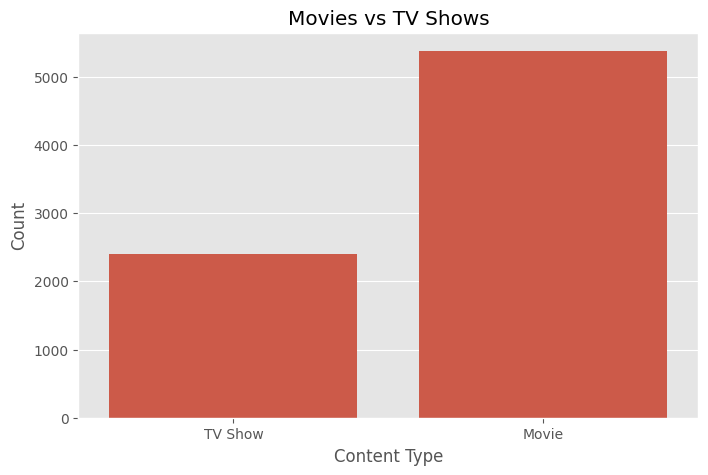

In [18]:
plt.figure(figsize=(8,5))

sns.countplot(
    data=df_clean,
    x='type'
)

plt.title('Movies vs TV Shows')

plt.xlabel('Content Type')

plt.ylabel('Count')

plt.show()

In [19]:
plt.savefig(
    'movies_vs_tvshows.png',
    bbox_inches='tight'
)

<Figure size 640x480 with 0 Axes>

In [20]:
df_clean.isnull().sum()

,0
show_id,0
type,0
title,0
director,0
cast,0
country,0
date_added,0
release_year,0
rating,0
duration,0


In [21]:
df_clean[['date_added','year_added','month_added','month_name']].head()

,date_added,year_added,month_added,month_name
0,2020-08-14,2020,8,August
1,2017-12-15,2017,12,December
2,2019-01-05,2019,1,January
3,2016-03-01,2016,3,March
4,2018-12-03,2018,12,December


In [22]:
print("Total Titles:", total_titles)
print("Total Movies:", total_movies)
print("Total TV Shows:", total_tvshows)
print("Countries:", total_countries)
print("Genres:", total_genres)
print("Average Content Age:", round(avg_content_age,2))

Total Titles: 7777
Total Movies: 5377
Total TV Shows: 2400
Countries: 682
Genres: 491
Average Content Age: 12.06


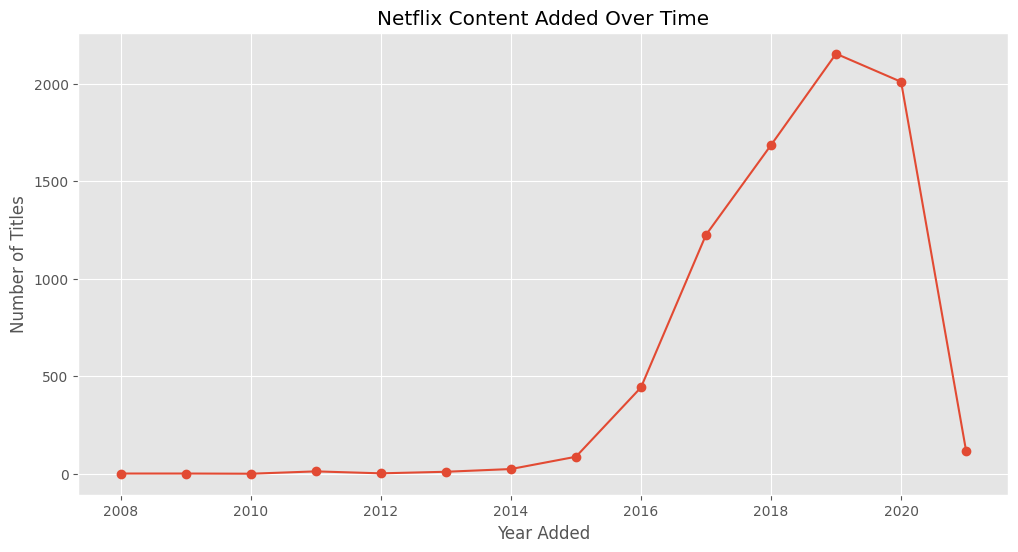

In [23]:
content_growth = (
    df_clean
    .groupby('year_added')
    .size()
)

plt.figure(figsize=(12,6))

content_growth.plot(
    marker='o'
)

plt.title('Netflix Content Added Over Time')

plt.xlabel('Year Added')

plt.ylabel('Number of Titles')

plt.grid(True)

plt.show()

In [24]:
plt.savefig(
    'content_added_over_time.png',
    bbox_inches='tight'
)

<Figure size 640x480 with 0 Axes>

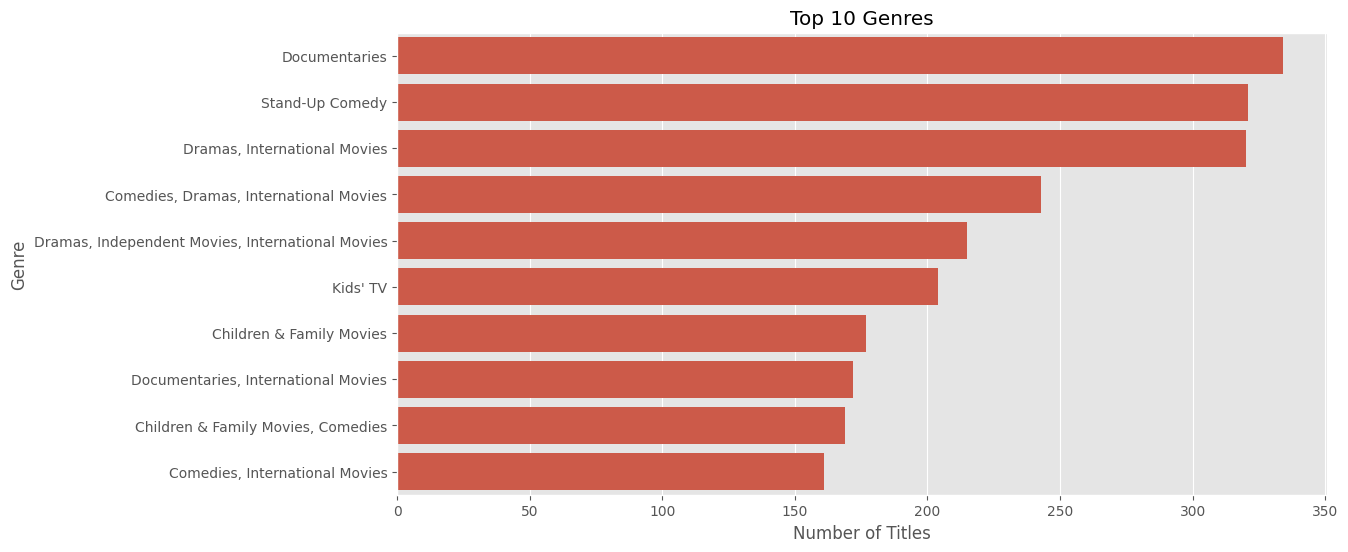

In [25]:
top_genres = (
    df_clean['genres']
    .value_counts()
    .head(10)
)

plt.figure(figsize=(12,6))

sns.barplot(
    x=top_genres.values,
    y=top_genres.index
)

plt.title('Top 10 Genres')

plt.xlabel('Number of Titles')

plt.ylabel('Genre')

plt.show()

In [26]:
plt.savefig(
    'top_genres.png',
    bbox_inches='tight'
)

<Figure size 640x480 with 0 Axes>

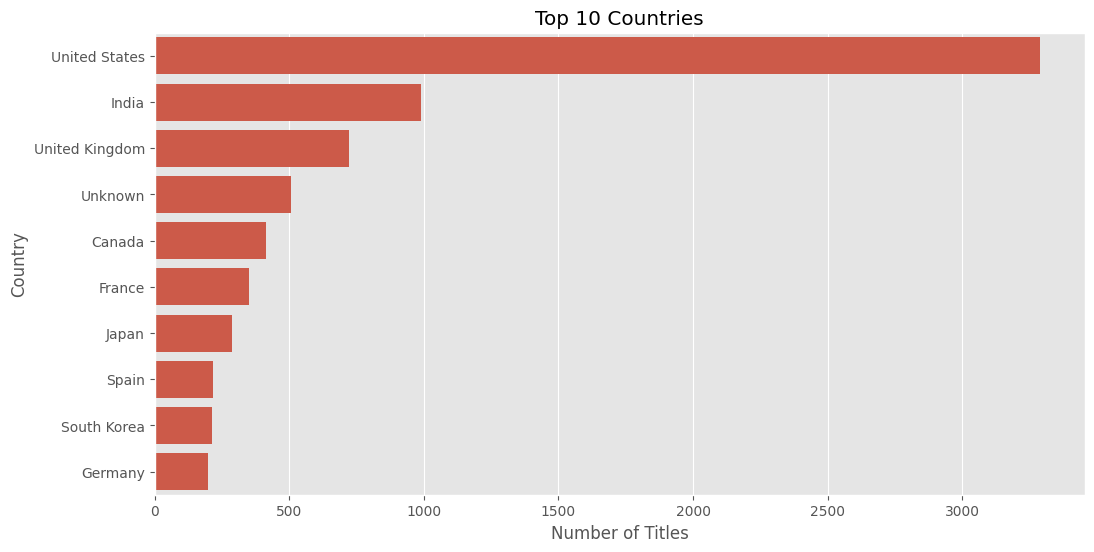

In [27]:
countries = (
    df_clean['country']
    .str.split(', ')
    .explode()
)

country_count = (
    countries
    .value_counts()
    .head(10)
)

plt.figure(figsize=(12,6))

sns.barplot(
    x=country_count.values,
    y=country_count.index
)

plt.title('Top 10 Countries')

plt.xlabel('Number of Titles')

plt.ylabel('Country')

plt.show()

In [28]:
plt.savefig(
    'top_countries.png',
    bbox_inches='tight'
)

<Figure size 640x480 with 0 Axes>

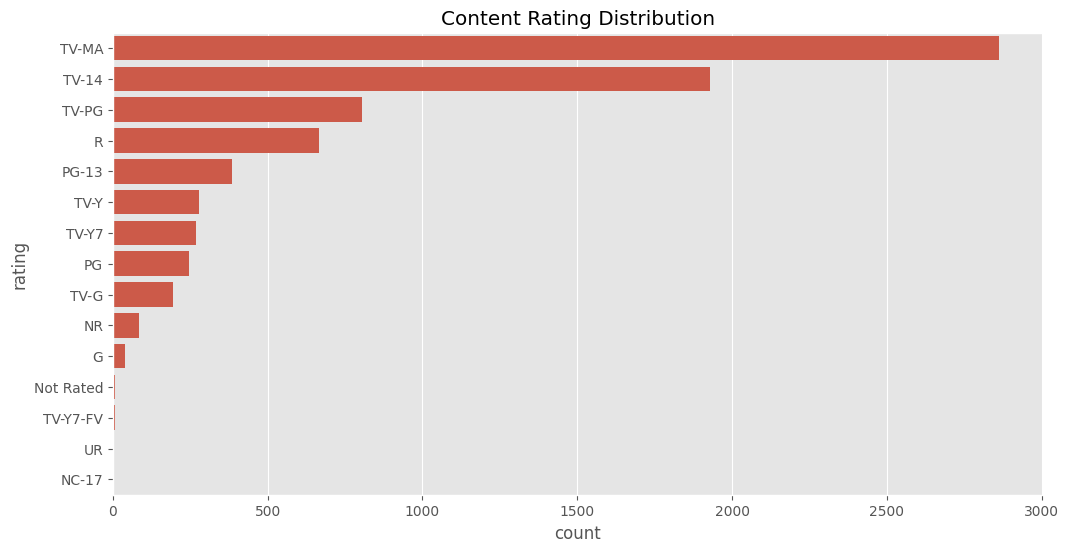

In [29]:
plt.figure(figsize=(12,6))

sns.countplot(
    data=df_clean,
    y='rating',
    order=df_clean['rating'].value_counts().index
)

plt.title('Content Rating Distribution')

plt.show()

In [30]:
plt.savefig(
    'rating_distribution.png',
    bbox_inches='tight'
)

<Figure size 640x480 with 0 Axes>

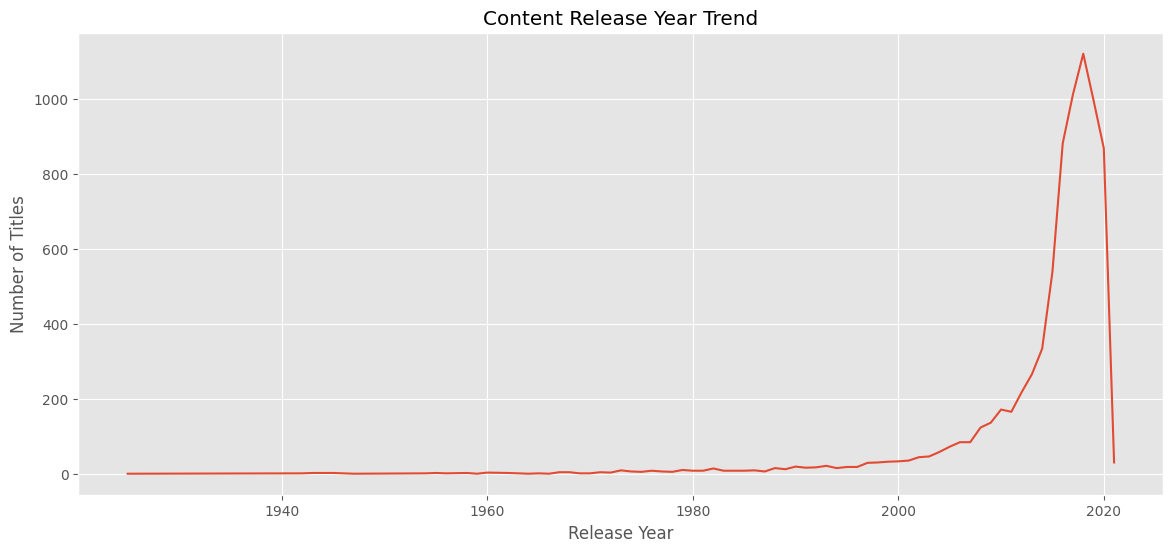

In [31]:
release_trend = (
    df_clean['release_year']
    .value_counts()
    .sort_index()
)

plt.figure(figsize=(14,6))

release_trend.plot()

plt.title('Content Release Year Trend')

plt.xlabel('Release Year')

plt.ylabel('Number of Titles')

plt.grid(True)

plt.show()

In [32]:
plt.savefig(
    'release_year_trend.png',
    bbox_inches='tight'
)

<Figure size 640x480 with 0 Axes>

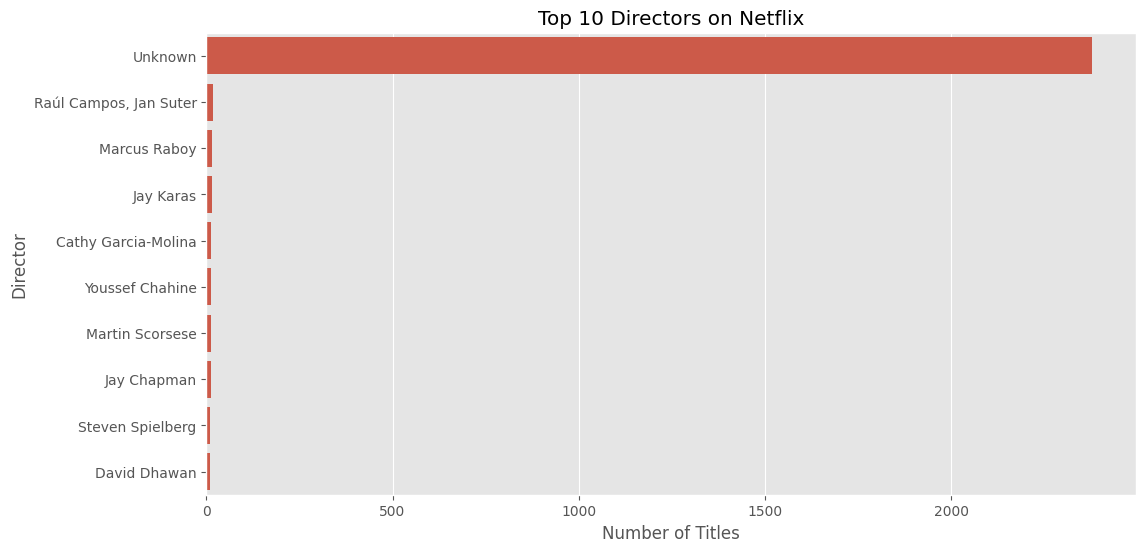

In [33]:
top_directors = (
    df_clean['director']
    .value_counts()
    .head(10)
)

plt.figure(figsize=(12,6))

sns.barplot(
    x=top_directors.values,
    y=top_directors.index
)

plt.title('Top 10 Directors on Netflix')
plt.xlabel('Number of Titles')
plt.ylabel('Director')

plt.show()

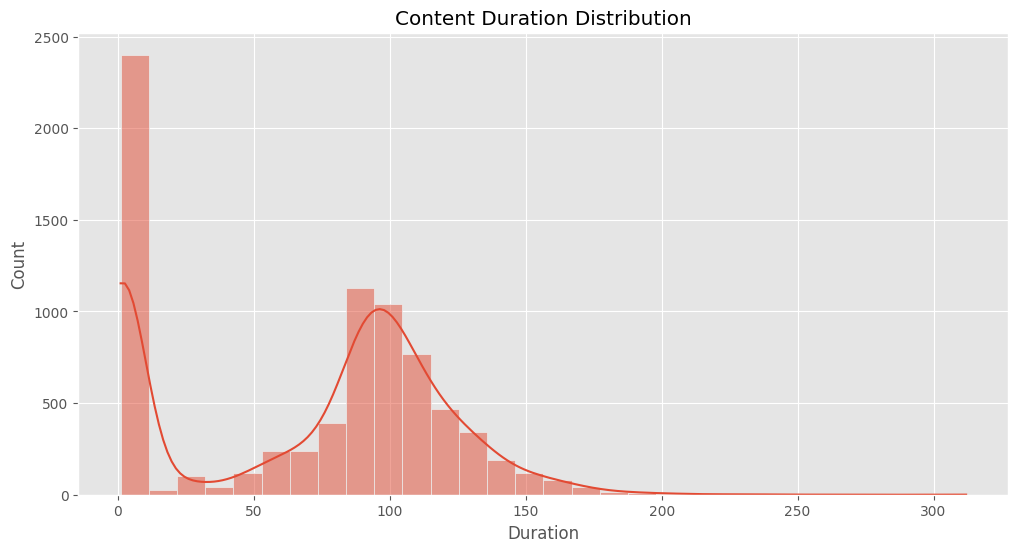

In [34]:
plt.figure(figsize=(12,6))

sns.histplot(
    df_clean['duration'],
    bins=30,
    kde=True
)

plt.title('Content Duration Distribution')

plt.xlabel('Duration')
plt.ylabel('Count')

plt.show()

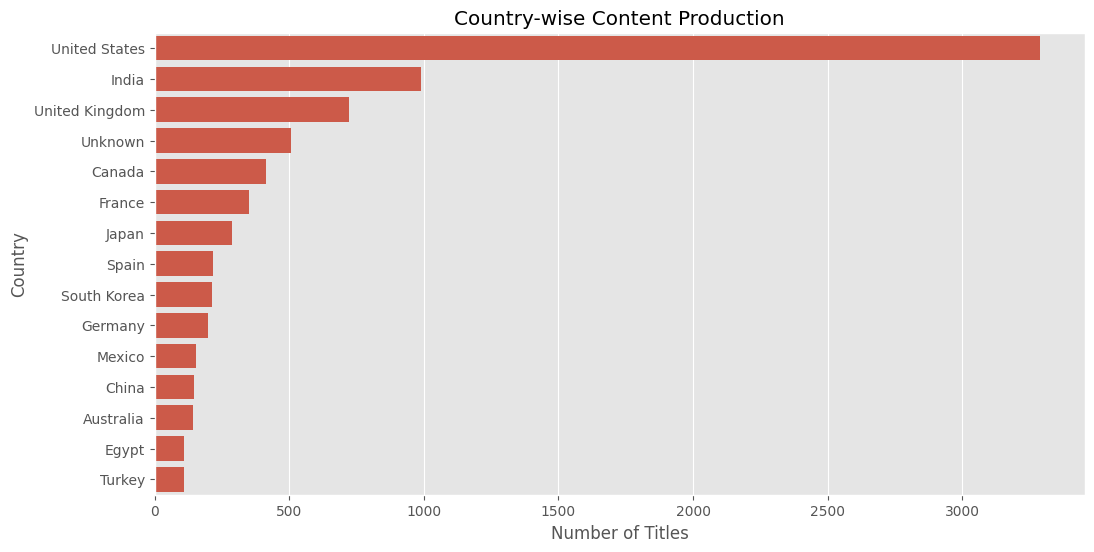

In [35]:
country_production = (
    countries
    .value_counts()
    .head(15)
)

plt.figure(figsize=(12,6))

sns.barplot(
    x=country_production.values,
    y=country_production.index
)

plt.title('Country-wise Content Production')

plt.xlabel('Number of Titles')
plt.ylabel('Country')

plt.show()

In [36]:
content_share = (
    df_clean['type']
    .value_counts(normalize=True)
    *100
)

print(content_share)

type
Movie      69.139771
TV Show    30.860229
Name: proportion, dtype: float64


In [37]:
df_clean.groupby(
    'type'
)['release_year'].mean()

,release_year
type,
Movie,2012.920030
TV Show,2016.212083


In [38]:
df_clean['year_added'].value_counts().head(10)

,count
year_added,
2019,2153
2020,2009
2018,1685
2017,1225
2016,443
2021,117
2015,88
2014,25
2011,13


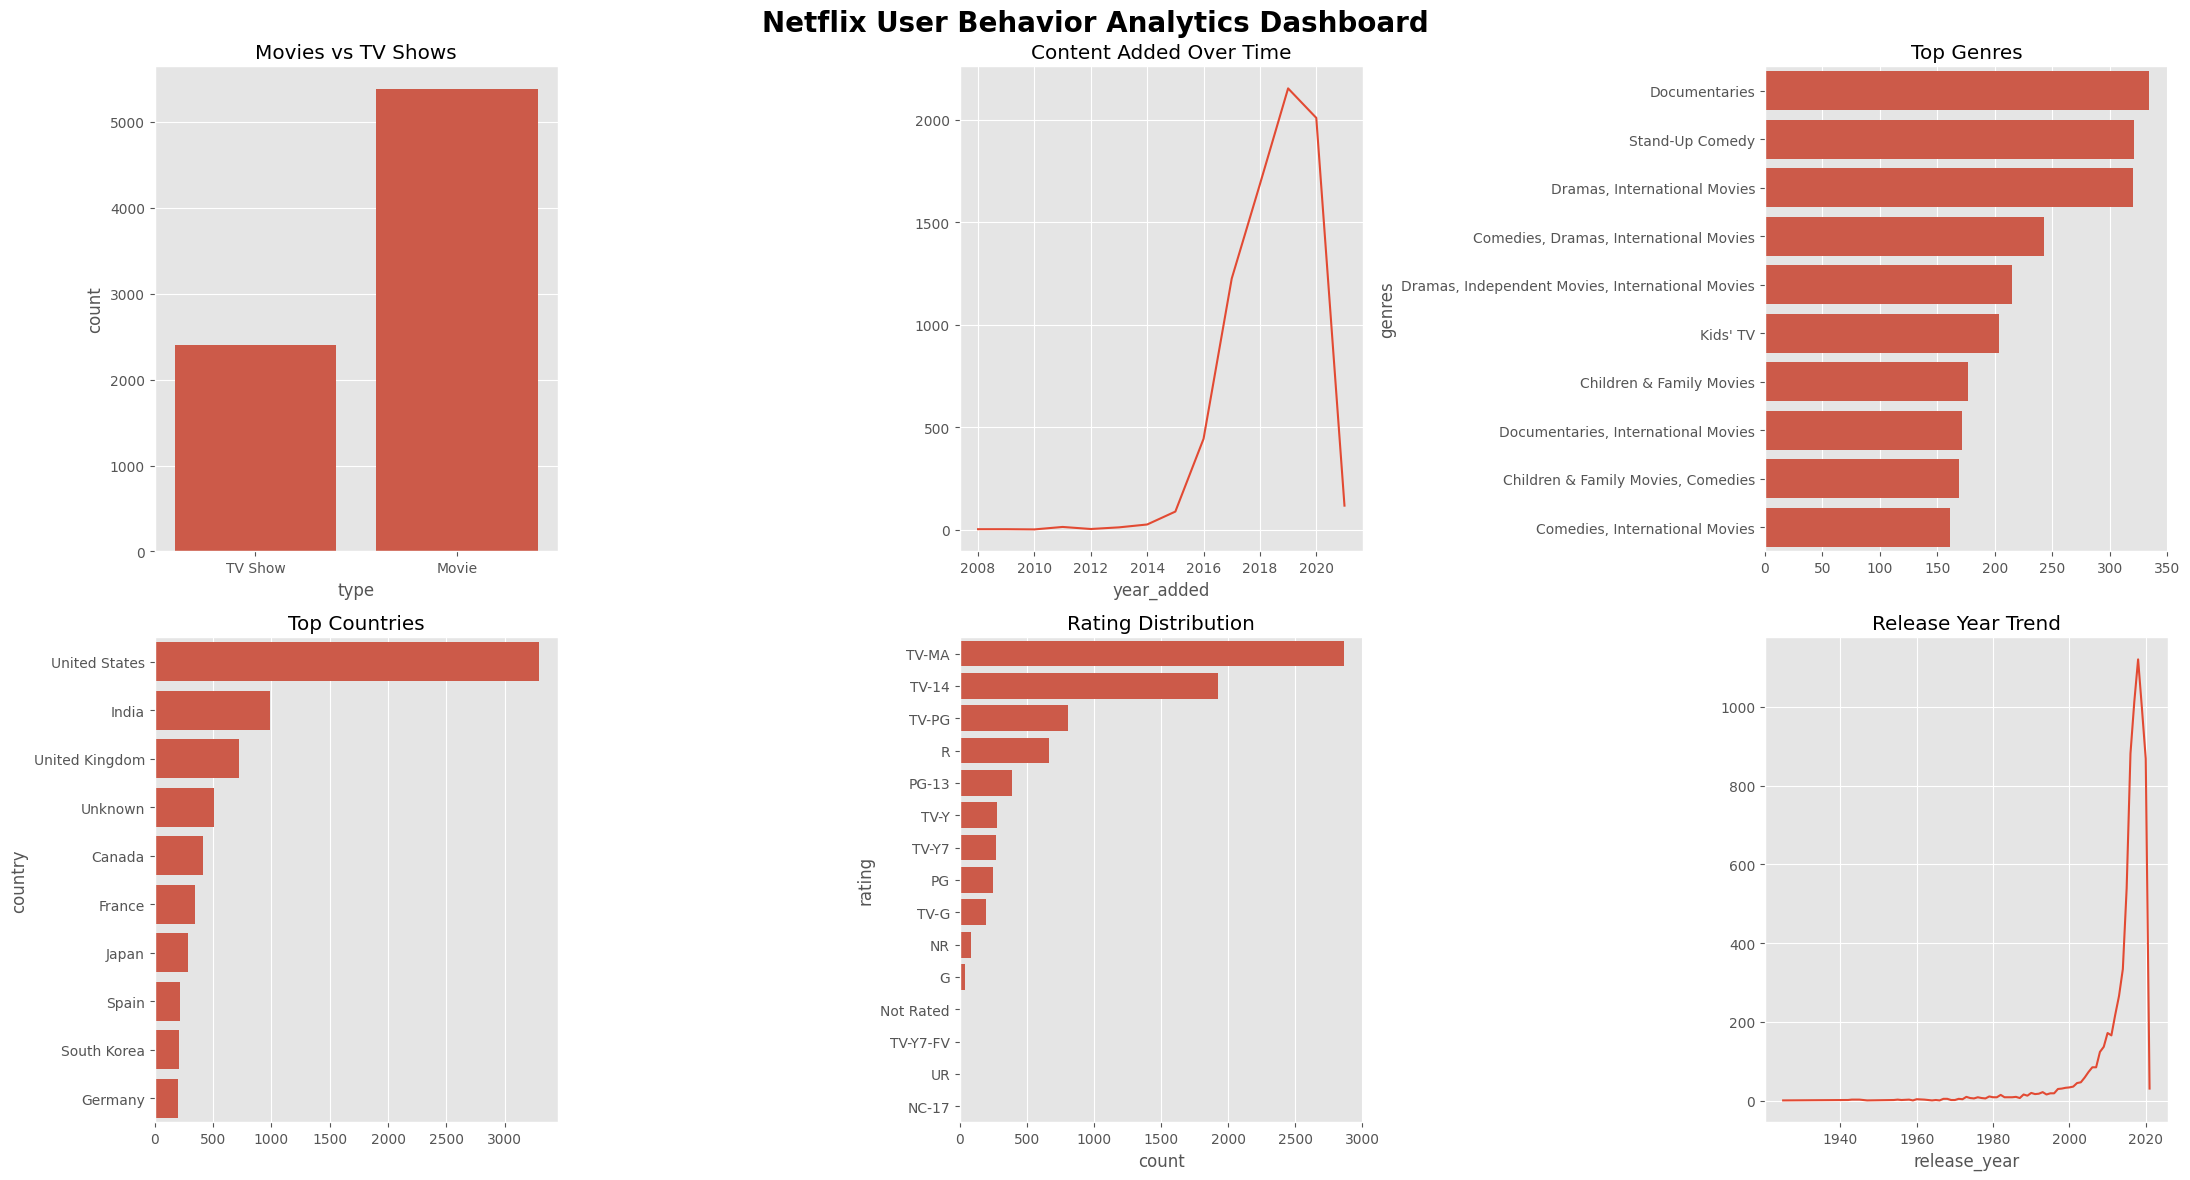

In [39]:
fig, axes = plt.subplots(
    2,
    3,
    figsize=(22,12)
)

# Chart 1
sns.countplot(
    data=df_clean,
    x='type',
    ax=axes[0,0]
)
axes[0,0].set_title('Movies vs TV Shows')

# Chart 2
content_growth.plot(
    ax=axes[0,1]
)
axes[0,1].set_title('Content Added Over Time')

# Chart 3
sns.barplot(
    x=top_genres.values,
    y=top_genres.index,
    ax=axes[0,2]
)
axes[0,2].set_title('Top Genres')

# Chart 4
sns.barplot(
    x=country_count.values,
    y=country_count.index,
    ax=axes[1,0]
)
axes[1,0].set_title('Top Countries')

# Chart 5
sns.countplot(
    data=df_clean,
    y='rating',
    order=df_clean['rating'].value_counts().index,
    ax=axes[1,1]
)
axes[1,1].set_title('Rating Distribution')

# Chart 6
release_trend.plot(
    ax=axes[1,2]
)
axes[1,2].set_title('Release Year Trend')

plt.suptitle(
    'Netflix User Behavior Analytics Dashboard',
    fontsize=20,
    fontweight='bold'
)

plt.tight_layout()

plt.show()